In [ ]:
import blackjax
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # notebook is in Toy Data/; Better_HMC.py is one level up
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import jax
import jax.random as jr
import arviz as az
import jax.scipy.special as jss
from functools import partial
# Import the custom package you generated
from hmc_dust.better_hmc import HMCSampler 
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)
#

num_dimensions = 250
num_data = 100
noise_magnitude_on_each_point = 0.03
num_fourier_entries = 350
total_length = 0.5
dx = total_length/(num_dimensions - 1)
fixed_points_linspace = jnp.arange(num_dimensions)*dx 
full_fourier_period_linspace = jnp.arange(num_fourier_entries)*dx 
boundary_padding = total_length*((num_fourier_entries - num_dimensions)/(num_dimensions - 1))
omegas = 2 * jnp.pi * jnp.fft.fftfreq(num_fourier_entries, d = dx)
fourier_length = total_length + boundary_padding
normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)

num_fitting_params = 4

# change this to overall variance
# try integrating numerically 
hardcoded_log_overall_variance = 0
hardcoded_log_exponent = 1
hardcoded_log_zero_mean = -6
hardcoded_log_zero_logvar = -2


hardcoded_params = (hardcoded_log_overall_variance, hardcoded_log_exponent, hardcoded_log_zero_mean, hardcoded_log_zero_logvar)
num_overall_steps = 6000
burn_in = 1000

num_integration_steps = 600
step_size = 0.002

use_NUTS = False
use_blackjax_hmc = False
window_adapt_square_mass_matrix = False

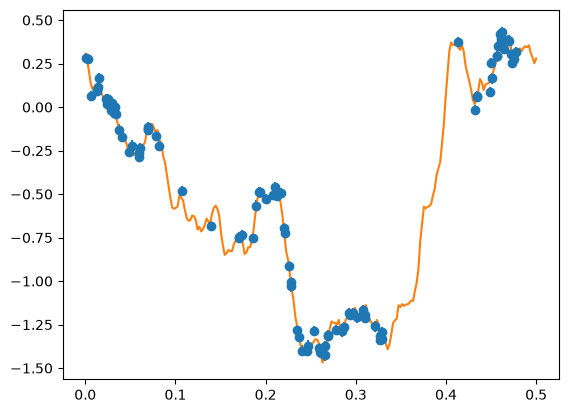

In [245]:
def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def power_law_field(xi, inference_params):
    log_overall_variance, log_exponent, log_zero_mean, log_zero_logvar = inference_params
    exponent = -1*jnp.exp(log_exponent)
    log_zero_std = jnp.exp(0.5*log_zero_logvar)        # not sqrt(exp(...))

    log_first_power = log_zero_mean + xi[0]*log_zero_std

    omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_entries, d=dx)[1:]
    log_powers = exponent * jnp.log(jnp.abs(omegas))
    log_sum_powers = jax.scipy.special.logsumexp(log_powers)

    # log(overall_variance * fourier_length / (first_power + sum(powers)))
    log_scale = (log_overall_variance + jnp.log(fourier_length)
                 - jnp.logaddexp(log_first_power, log_sum_powers))

    first_amp = jnp.exp(0.5*(log_first_power + log_scale))
    amps      = jnp.exp(0.5*(log_powers      + log_scale))

    scaled_noise = jnp.concatenate([xi[1:2]*first_amp, xi[2:]*amps])
    field = hartley(scaled_noise)/jnp.sqrt(fourier_length)
    return field[:num_dimensions]
def cdf(x):
    return x + jnp.sin(4 * jnp.pi * x) / (4 * jnp.pi)

def pdf(x):
    return 1 + jnp.cos(4 * jnp.pi * x)

@partial(jax.jit, static_argnames=("n", "iters"))
def sample(key, n, iters=8):
    u = jr.uniform(key, (n,))
    x = u  # good initial guess since CDF(x) ≈ x on average
    for _ in range(iters):
        x = x - (cdf(x) - u) / pdf(x)   # Newton's method
        x = jnp.clip(x, 0.0, 1.0)
    return x

diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2

cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)

k1, k2, k3, k4 = jr.split(jr.key(25), 4)



x_obs = sample(k1, num_data)*total_length
xi = jr.normal(k3, shape = num_fourier_entries + 1)
true_field = power_law_field(xi, hardcoded_params)
y_obs_true = jnp.interp(x_obs, fixed_points_linspace, true_field)
#y_obs_true = jnp.sin(30*x_obs/10) * jnp.exp(-5*x_obs/10)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)
noise = y_obs_err * jr.normal(k2, shape=y_obs_true.shape)
y_obs = y_obs_true + noise


plt.errorbar(x_obs, y_obs, yerr = noise_magnitude_on_each_point, fmt='o', label='Observations')

plt.plot(fixed_points_linspace, true_field)
def response_function(xi, inference_params):
    field_points = power_law_field(xi, inference_params)
    return jnp.interp(x_obs, fixed_points_linspace, field_points)

In [246]:
def log_params_prior(inference_params):
    log_overall_variance, log_exponent, log_zero_mean, log_zero_var = inference_params 
    return -0.5*log_overall_variance**2 - 0.5*log_exponent**2 - 0.5*log_zero_mean**2 - 0.5*log_zero_var**2

def negative_logdensity(x):
    inference_params, xi = tuple(x[:num_fitting_params]), x[num_fitting_params:]
    negative_log_p_s = -log_params_prior(inference_params) + 0.5*xi.T @ xi
    res = y_obs - response_function(xi, inference_params)
    negative_log_p_d_given_s = 0.5*res.T @ inv_cov_data_matrix @ res
    return negative_log_p_s + negative_log_p_d_given_s


In [247]:
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)


# NUTS samples a POSITIVE log-density, so negate your negative one.
logdensity_fn = lambda x: -negative_logdensity(x)

rng = jr.PRNGKey(5)
rng, k1, k2 = jr.split(rng, 3)
initial_coordinates = jnp.zeros(num_fourier_entries + 1 + num_fitting_params)

initial_coordinates = initial_coordinates.at[0].set(hardcoded_log_overall_variance)
initial_coordinates = initial_coordinates.at[1].set(hardcoded_log_exponent)
initial_coordinates = initial_coordinates.at[2].set(hardcoded_log_zero_mean)
initial_coordinates = initial_coordinates.at[3].set(hardcoded_log_zero_logvar)

if(use_NUTS):
        def inference_loop(rng_key, kernel, initial_state, num_samples):
            @jax.jit
            def one_step(state, key):
                state, info = kernel(key, state)
                return state, (state, info)
            keys = jr.split(rng_key, num_samples)
            _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)
            return states, infos


        warmup = blackjax.window_adaptation(blackjax.nuts, logdensity_fn, is_mass_matrix_diagonal= not window_adapt_square_mass_matrix)
        (state, parameters), _ = warmup.run(k1, initial_coordinates, num_steps=burn_in)
        nuts = blackjax.nuts(logdensity_fn, **parameters)
        initial_state = state

        states, infos = inference_loop(k2, nuts.step, initial_state, num_good_samples)

        overall_data_arr = states.position
        accept_prob_arr  = infos.acceptance_rate
elif use_blackjax_hmc:
    def inference_loop(rng_key, kernel, initial_state, num_samples):
        @jax.jit
        def one_step(state, key):
            state, info = kernel(key, state)
            return state, (state, info)
        keys = jr.split(rng_key, num_samples)
        _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)
        return states, infos

    warmup = blackjax.window_adaptation(
        blackjax.hmc, logdensity_fn,
        num_integration_steps=num_integration_steps,
        is_mass_matrix_diagonal=not window_adapt_square_mass_matrix,
    )
    (state, parameters), _ = warmup.run(k1, initial_coordinates, num_steps=burn_in)

    hmc = blackjax.hmc(logdensity_fn, **parameters)
    initial_state = state

    states, infos = inference_loop(k2, hmc.step, initial_state, num_good_samples)

    overall_data_arr = states.position
    accept_prob_arr  = infos.acceptance_rate
    np.save('blackjax_cov_matrix.npy', np.asarray(parameters["inverse_mass_matrix"]))
else :
    sampler = HMCSampler(
        negative_logdensity= negative_logdensity,
        num_integration_steps =  num_integration_steps,
        step_size= step_size,
        inv_mass_matrix = jnp.eye(num_fourier_entries + 1 + num_fitting_params),
        alpha=1.0
    )

    overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
        start_position=initial_coordinates, 
        num_samples=num_overall_steps,
        burn_in = burn_in,
        rng_key=rng
    )

#overall_data_arr = jnp.zeros(shape = (num_good_samples, num_fourier_entries + 1 + num_fitting_params))
#accept_prob_arr = jnp.zeros(shape = num_good_samples)


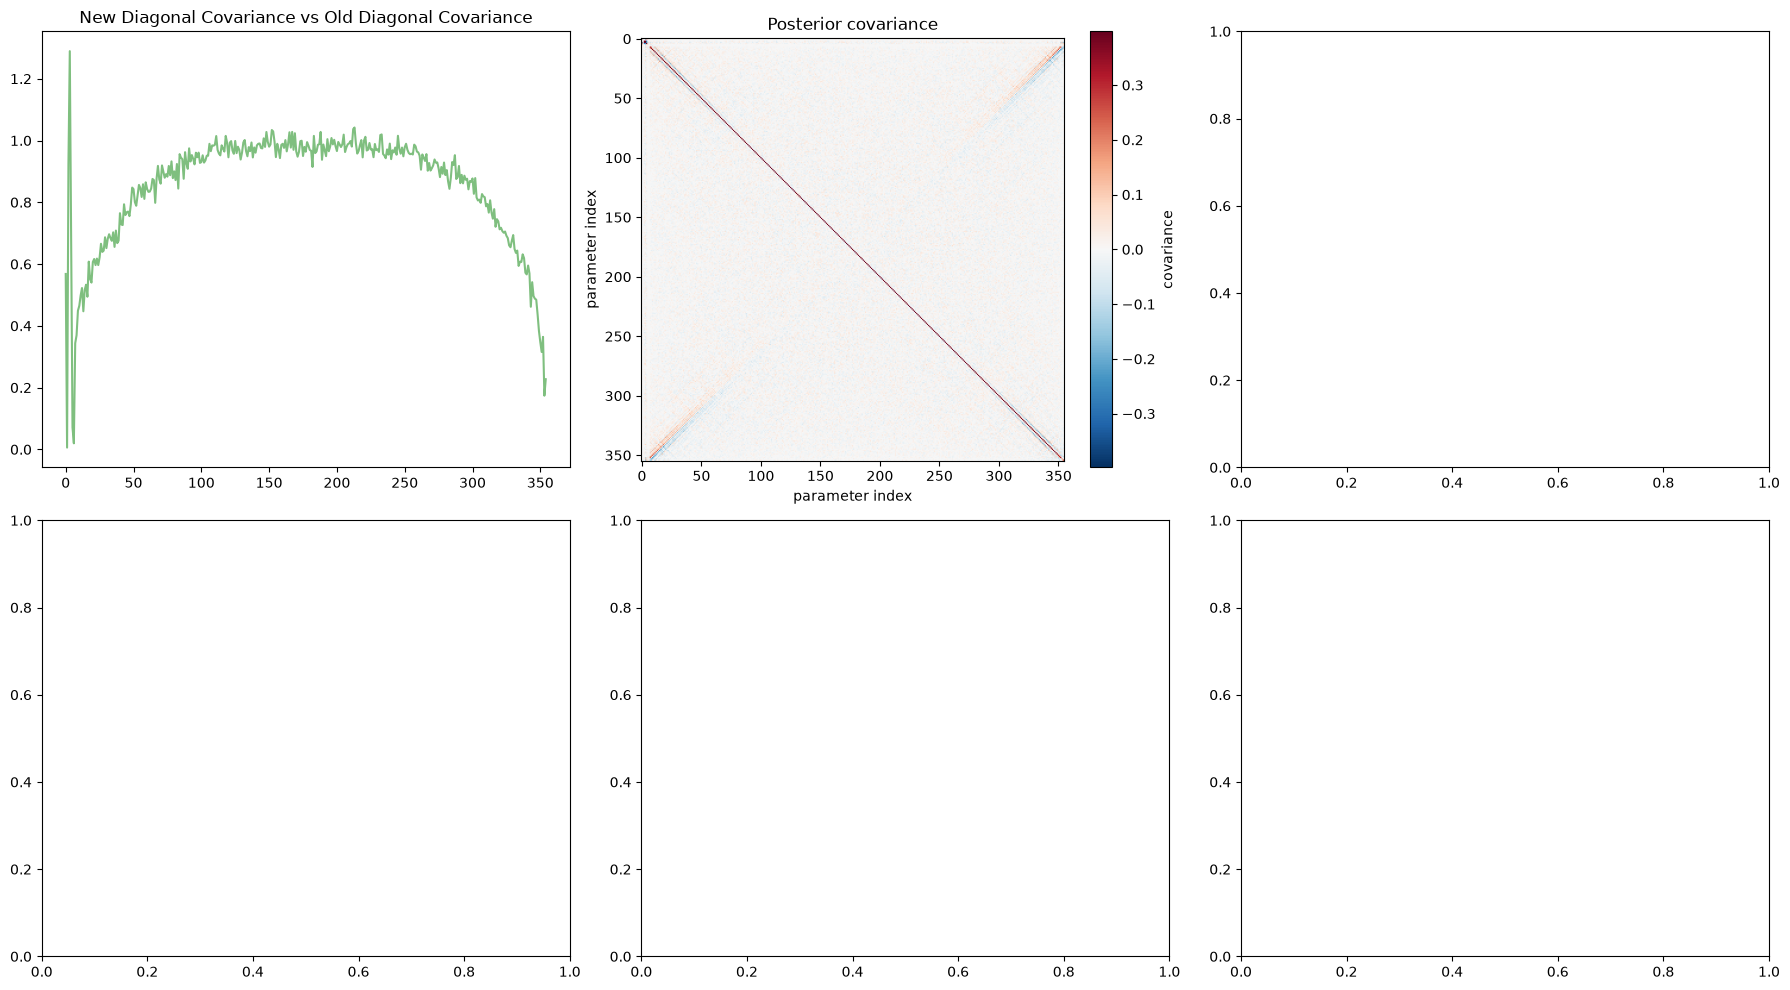

In [ ]:
log_overall_variances = overall_data_arr[:, 0]
log_exponents = overall_data_arr[:, 1]
log_zero_means = overall_data_arr[:, 2]
log_zero_logvars = overall_data_arr[:, 3]
overall_position_arr = overall_data_arr[:, num_fitting_params:]  


def field_from_sample(sample):
    inference_params, xi = tuple(sample[:num_fitting_params]), sample[num_fitting_params:]
    return power_law_field(xi, inference_params)

overall_position_arr = jax.lax.map(jax.jit(field_from_sample), overall_data_arr)

mean_position = overall_position_arr.sum(axis=0)/num_good_samples

cov= jnp.cov(overall_data_arr, rowvar = False)


fig, axes = plt.subplots(2, 3, figsize = (18, 10))
timegrid = jnp.arange(num_fourier_entries + 1 + num_fitting_params)
axes[0][0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
#axes[0].plot(timegrid, jnp.diagonal(old_cov), color = "Red", alpha = 0.5)
axes[0][0].set_title("New Diagonal Covariance vs Old Diagonal Covariance")


C = np.asarray(cov)
off = C - np.diag(np.diag(C))
vmax = np.abs(off).max()         # symmetric limits so white = 0
im = axes[0][1].imshow(C, cmap='RdBu_r', vmin= -vmax, vmax=vmax)
fig.colorbar(im, ax=axes[0][1], label='covariance')
axes[0][1].set_title('Posterior covariance')
axes[0][1].set_xlabel('parameter index')
axes[0][1].set_ylabel('parameter index')


if use_NUTS or use_blackjax_hmc:
    step_size = parameters['step_size']
    inv_mass_matrix = parameters['inverse_mass_matrix']   # not 'inv_mass_matrix'
    if(window_adapt_square_mass_matrix):
        C = np.asarray(inv_mass_matrix)
        off = C - np.diag(np.diag(C))
        vmax = np.abs(off).max()        
        im = axes[1][0].imshow(jnp.log(C), cmap='RdBu_r', vmin= -vmax, vmax=vmax)
        axes[1][0].colorbar(im, ax=axes[0], label='covariance')
        axes[1][0].set_title('Posterior covariance')
        axes[1][0].set_xlabel('parameter index')
        axes[1][0].set_ylabel('parameter index')
        axes[1][1].plot(jnp.arange(jnp.diagonal(inv_mass_matrix)).size, inv_mass_matrix)
    else :
        axes[1][0].plot(jnp.arange(inv_mass_matrix.size), inv_mass_matrix)

plt.tight_layout()
plt.show()

ESS for variance: 979.0905255660399
KL_divergence is 1.5552859926655684 with jitter 0.0002
Average acceptance probability (acceptance rate) is: 0.8389999679867793
Num overall steps: 6000 Hardcoded params: (0, 1, -6, -2) 
Use NUTS? False Use blackjax HMC? False Step Size: 0.002 Num integration steps (only valid if no NUTS) 600
Num dimensions: 250 Num data: 100 Total length: 0.5 Noise on each point: 0.03 Num HMC trials: 6000
Average chi_2 statistic based on the prior: 0.85742357693927
Average chi_2 statistic based on the data per data point: 0.8338669669235198
Binning of the analytical posterior (finer bins --> lower KL div): 40 by 40


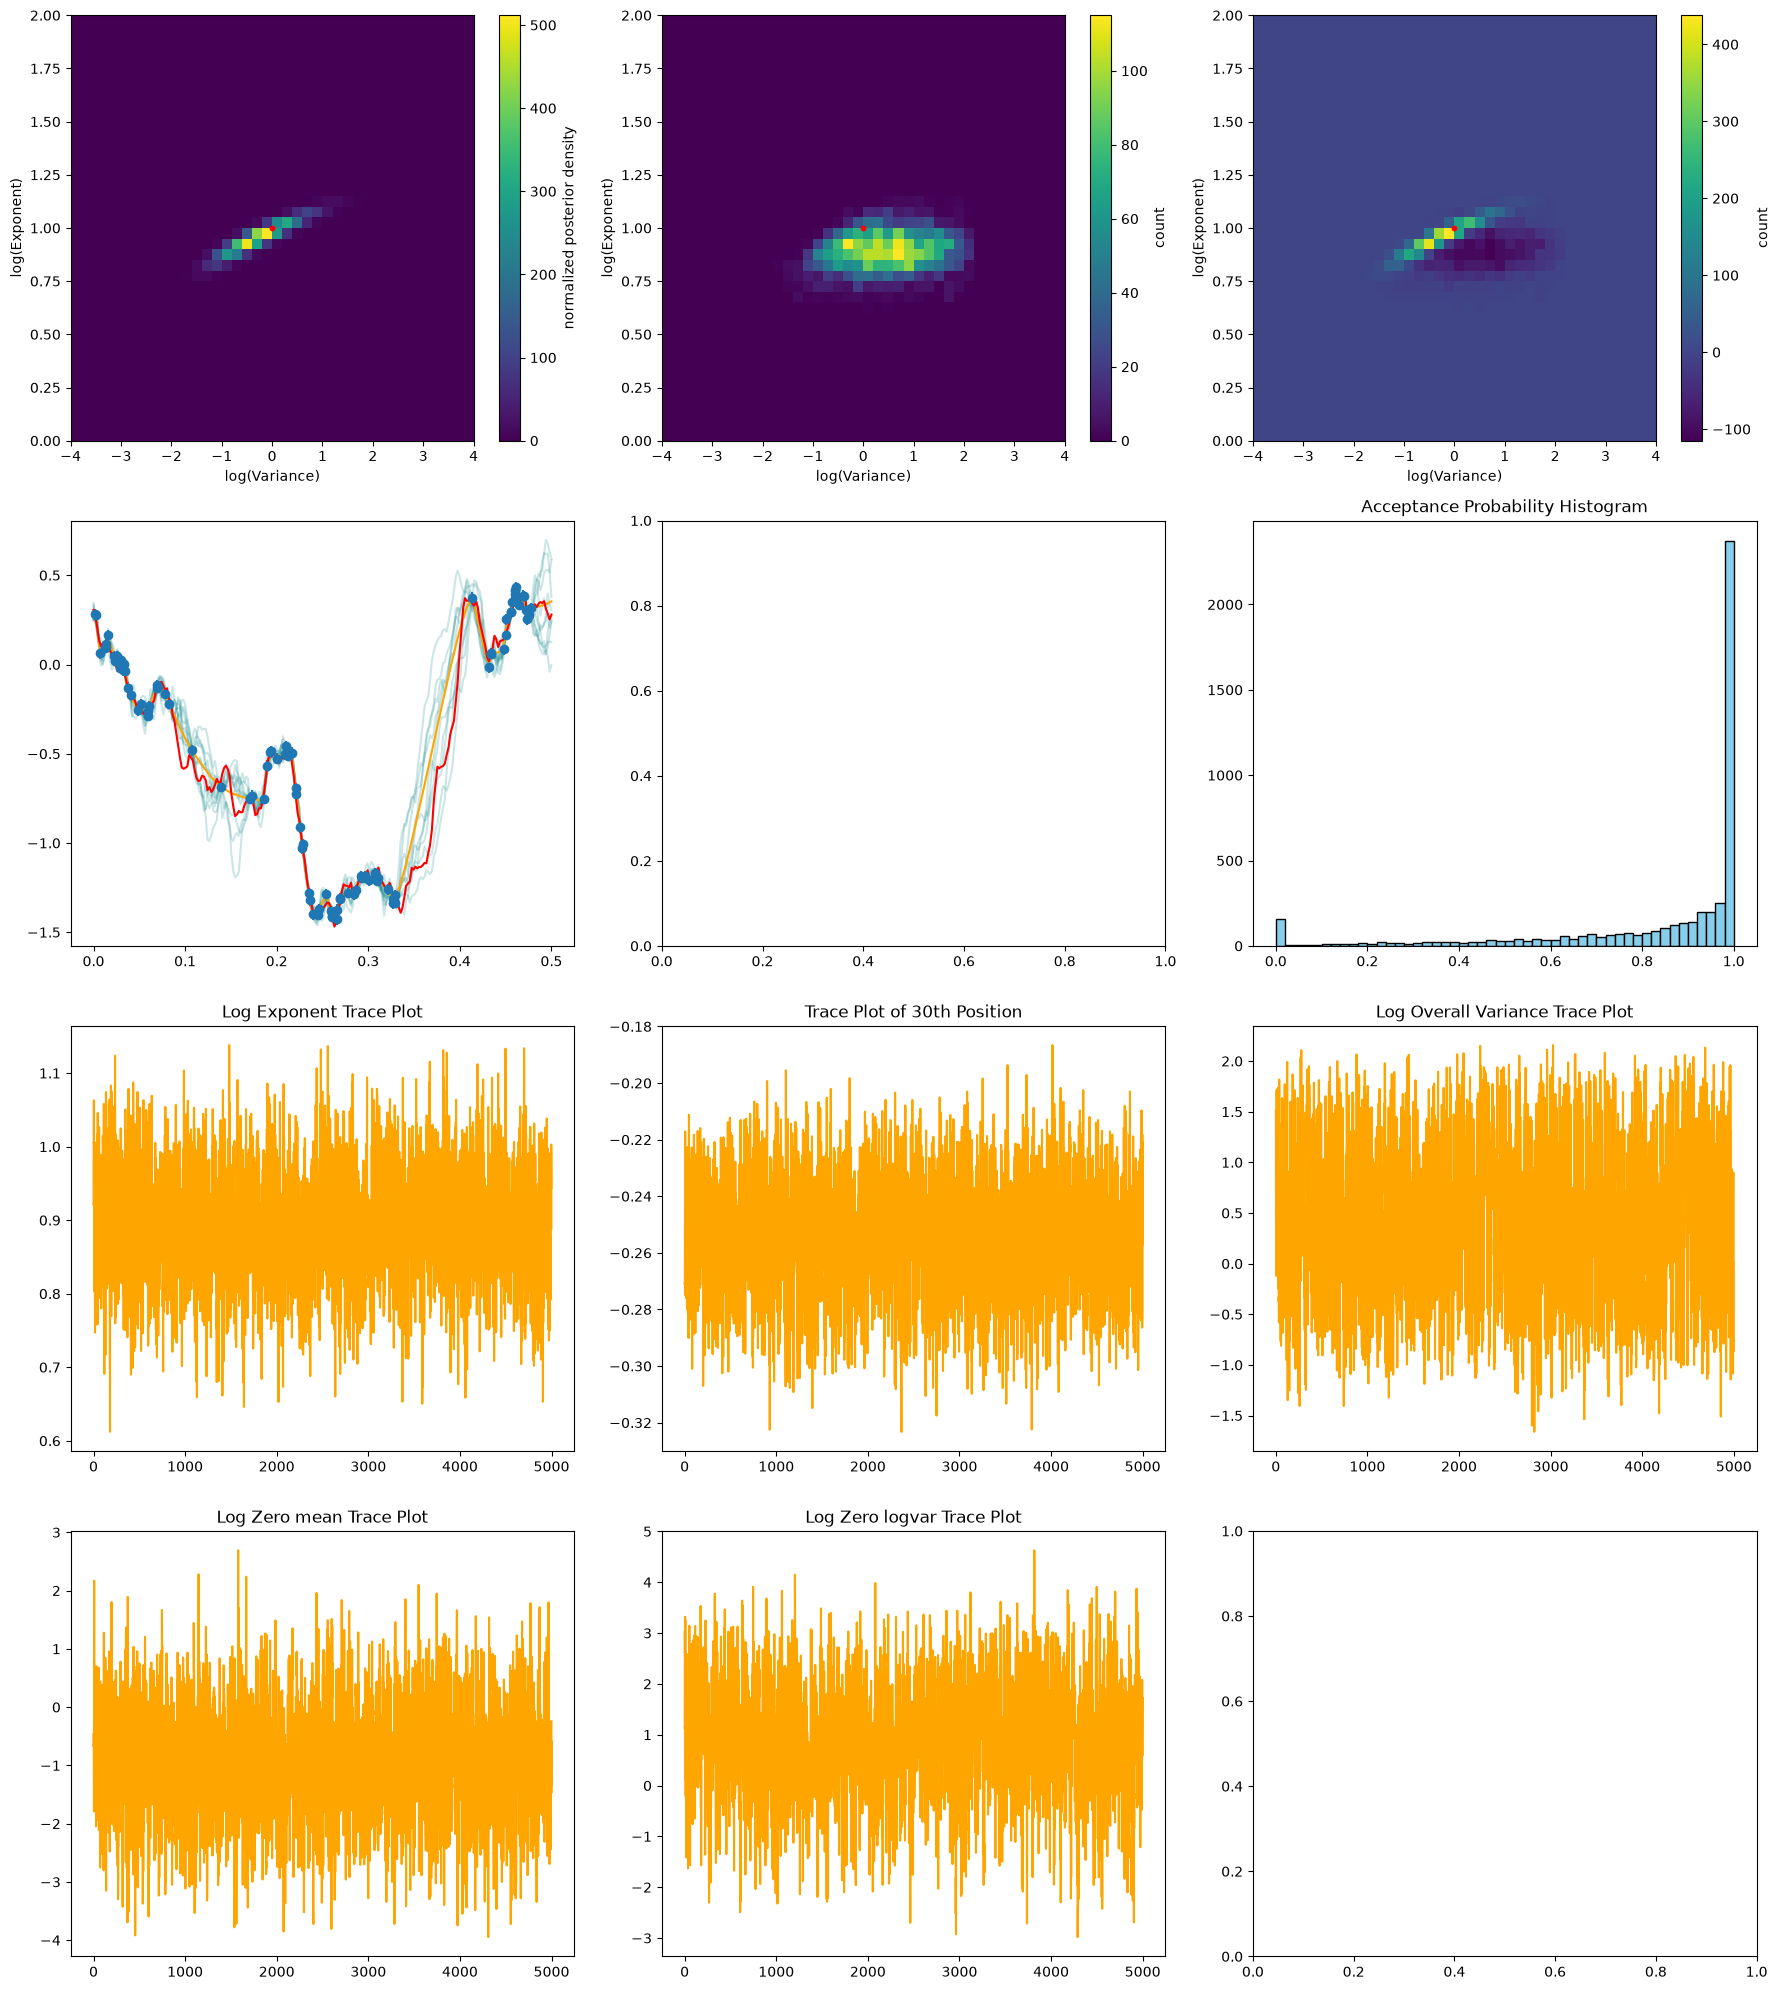

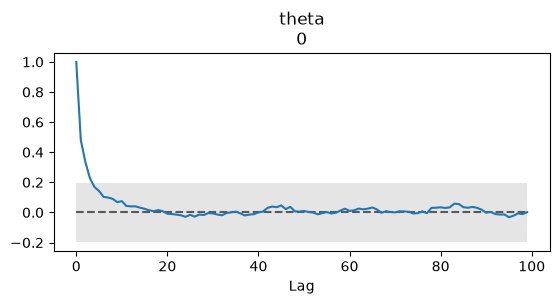

In [250]:
fig, axes = plt.subplots(4, 3, figsize = (18, 20))
for i in range (0, 10):
    axes[1][0].plot(fixed_points_linspace, overall_position_arr[500*i, :], color = "teal", alpha = 0.2)

axes[1][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
axes[1][0].plot(fixed_points_linspace, mean_position, color = "orange", alpha = 1)
axes[1][0].plot(fixed_points_linspace, true_field, color = "red", alpha = 1)


def log_posterior_density(inference_params):
    logprior = log_params_prior(inference_params)
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries + 1))
    jitter = 0
    total_cov_on_data = R @ R.T + cov_data_matrix + jitter
    cho_factor = jsp.linalg.cho_factor(total_cov_on_data)
    solve_val = jsp.linalg.cho_solve(cho_factor, y_obs)
    log_p_data_given_params = -0.5 * (y_obs @ solve_val)
    logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(cho_factor[0])))
    return log_p_data_given_params + logprior - 0.5 * logdet 


def max_log_posterior_density(inference_params):
    log_pd = log_posterior_density(inference_params)
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries + 1))
    D = jnp.linalg.inv(jnp.eye(num_fourier_entries + 1) + R.T @ inv_cov_data_matrix @ R)
    _, logdet = jnp.linalg.slogdet(D)
    return log_pd - 0.5*logdet


number_bins_x = 40
number_bins_y = 40

x_min, x_max = hardcoded_log_overall_variance - 4, hardcoded_log_overall_variance + 4
y_min, y_max = hardcoded_log_exponent - 1, hardcoded_log_exponent + 1
dx_plot = (x_max - x_min)/number_bins_x
dy_plot = (y_max - y_min)/number_bins_y

x_centers = (jnp.arange(number_bins_x) + 0.5)*dx_plot + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy_plot + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx_plot + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy_plot + y_min

X, Y = jnp.meshgrid(x_centers, y_centers, indexing='ij')

F = lambda lv, le: log_posterior_density((lv, le, hardcoded_log_zero_mean, hardcoded_log_zero_logvar))
Z_flat = jax.lax.map(lambda pair: F(pair[0], pair[1]), (X.ravel(), Y.ravel()))
Z = Z_flat.reshape(X.shape)
Z = jnp.exp(Z - jnp.max(Z))
expected_posterior_counts = Z*num_good_samples/jnp.sum(Z)

im = axes[0][0].imshow(
    expected_posterior_counts.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][0], label='normalized posterior density')

H_HMC_samples, _, _ = jnp.histogram2d(log_overall_variances, log_exponents, bins=[x_edges, y_edges])

im2 = axes[0][1].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][1], label='count')

im3 = axes[0][2].imshow(
    (expected_posterior_counts - H_HMC_samples).T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im3, ax=axes[0][2], label='count')

axes[0][0].scatter(hardcoded_log_overall_variance, hardcoded_log_exponent, color = 'red', s = 10, zorder = 3)
axes[0][1].scatter(hardcoded_log_overall_variance, hardcoded_log_exponent, color = 'red', s = 10, zorder = 3)
axes[0][2].scatter(hardcoded_log_overall_variance, hardcoded_log_exponent, color = 'red', s = 10, zorder = 3)
axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Exponent)")
axes[0][1].set_xlabel("log(Variance)")
axes[0][1].set_ylabel("log(Exponent)")
axes[0][2].set_xlabel("log(Variance)")
axes[0][2].set_ylabel("log(Exponent)")
axes[2][2].plot(time_arr, log_overall_variances, color = "Orange")
axes[2][2].set_title("Log Overall Variance Trace Plot")
axes[2][0].plot(time_arr, log_exponents, color = "Orange")
axes[2][0].set_title("Log Exponent Trace Plot")
axes[3][0].set_title("Log Zero mean Trace Plot")
axes[3][0].plot(time_arr, log_zero_means, color = "Orange")
axes[3][1].set_title("Log Zero logvar Trace Plot")
axes[3][1].plot(time_arr, log_zero_logvars, color = "Orange")
axes[2][1].plot(time_arr, overall_position_arr[:, 30], color = "Orange")
axes[2][1].set_title("Trace Plot of 30th Position")
axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

fig.tight_layout()


posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})
param_index = 0  # which of your 50 parameters you want

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

ess_param = ess_all["theta"].sel(theta_dim_0=param_index).values
print(f"ESS for variance: {ess_param}")

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)
def average_chi_2_based_on_data(x_data, x_field, data, field, inverse_data_cov):
    interp_all_rows = jax.vmap(lambda row: jnp.interp(x_data, x_field, row))
    raw_field_at_data_points = interp_all_rows(field)
    residuals = raw_field_at_data_points - data
    chi_2 = jnp.einsum('ij,jk,ik->i', residuals, inverse_data_cov, residuals)
    return jnp.average(chi_2)/data.size

expected_bin_prob = expected_posterior_counts/num_good_samples
observed_bin_prob = H_HMC_samples/num_good_samples
print(f"KL_divergence is {KL_divergence(expected_bin_prob, observed_bin_prob, jitter = 1/num_good_samples)} with jitter {1/num_good_samples}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Num overall steps: {num_overall_steps} Hardcoded params: {hardcoded_params} ")
print(f"Use NUTS? {use_NUTS} Use blackjax HMC? {use_blackjax_hmc} Step Size: {step_size} Num integration steps (only valid if no NUTS) {num_integration_steps}")
print(f"Num dimensions: {num_dimensions} Num data: {num_data} Total length: {total_length} Noise on each point: {noise_magnitude_on_each_point} Num HMC trials: {num_overall_steps}")
prior_variances = jnp.diag(cov)[2:]
print(f"Average chi_2 statistic based on the prior: {jnp.average(prior_variances)}")
print(f"Average chi_2 statistic based on the data per data point: {average_chi_2_based_on_data(x_obs, fixed_points_linspace, y_obs, overall_position_arr, inv_cov_data_matrix)}")
print(f"Binning of the analytical posterior (finer bins --> lower KL div): {number_bins_x} by {number_bins_y}")